In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using Statistics, Distributions
using CairoMakie, MakiePublication
using Random, LsqFit

In [3]:
include("./GOF.jl")
include("./MacroPatterns.jl")

using .GOF
using .MacroPatterns

In [4]:
# Set theme for plots
__theme = MakiePublication.theme_acs(; ishollowmarkers=[true,true])
set_theme!(__theme)

In [5]:
rng = Random.Xoshiro(42)

# Generate a sample
data = rand(rng, Normal(100,20), 2000);

In [6]:
# Get parameters considering a normal distribution
μ = mean(data)
σ = std(data)

# Get paramaters considering a gamma distribution
α = mean(data)^2 / var(data)
θ = var(data) / mean(data)

println("normal: μ = $μ   σ = $σ")
println("gamma : α = $α   θ = $θ")

normal: μ = 99.23947206253551   σ = 20.149271889957518
gamma : α = 24.257731019789475   θ = 4.091045118011074


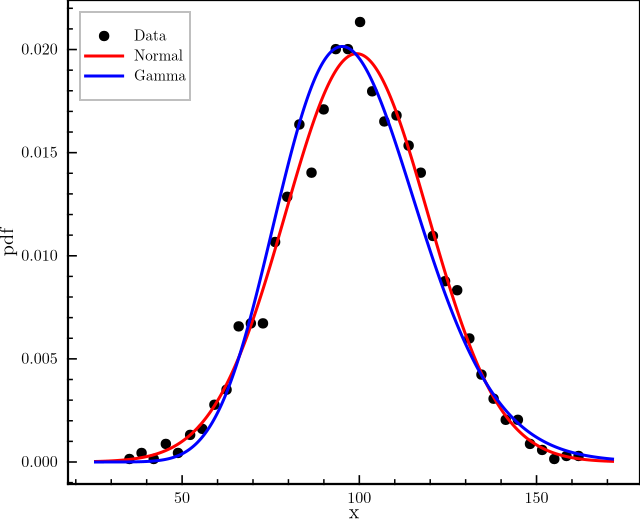

In [7]:
# Make histogram
x, y = MacroPatterns.make_hist(data, nbins=40)

# Plot histogram and inferred curves
fig = Figure(size=(320, 260))
ax = Axis(fig[1,1], xlabel="x", ylabel="pdf")

scatter!(ax, x, y, color=:black, label="Data", markersize=6)

xrange = minimum(x)-10:1e-2:maximum(x)+10
lines!(ax, xrange, pdf.(Normal(μ,σ), xrange), label="Normal", color=:red)
lines!(ax, xrange, pdf.(Gamma(α,θ), xrange), label="Gamma", color=:blue)

axislegend(ax, position=:lt, framevisible=true)

fig

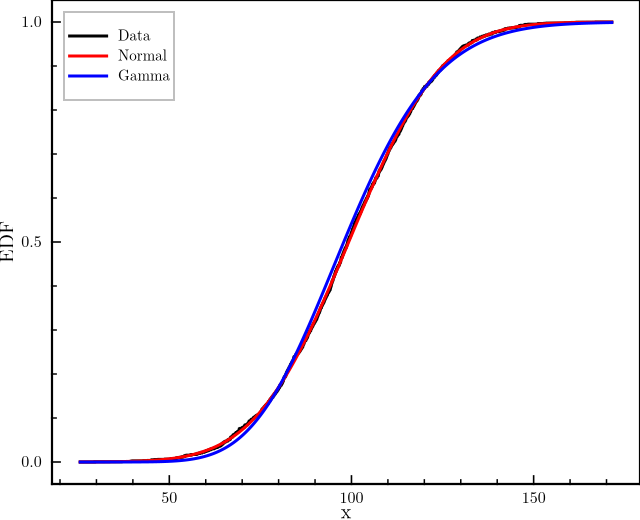

In [8]:
Fn = GOF.make_EDF(data, xrange)

fig = Figure(size=(320, 260))
ax = Axis(fig[1,1], xlabel="x", ylabel="EDF")

lines!(ax, xrange, Fn, color=:black, label="Data")
lines!(ax, xrange, cdf.(Normal(μ, σ), xrange), label="Normal", color=:red)
lines!(ax, xrange, cdf.(Gamma(α, θ), xrange), label="Gamma", color=:blue)
axislegend(ax, position=:lt, framevisible=true)

fig

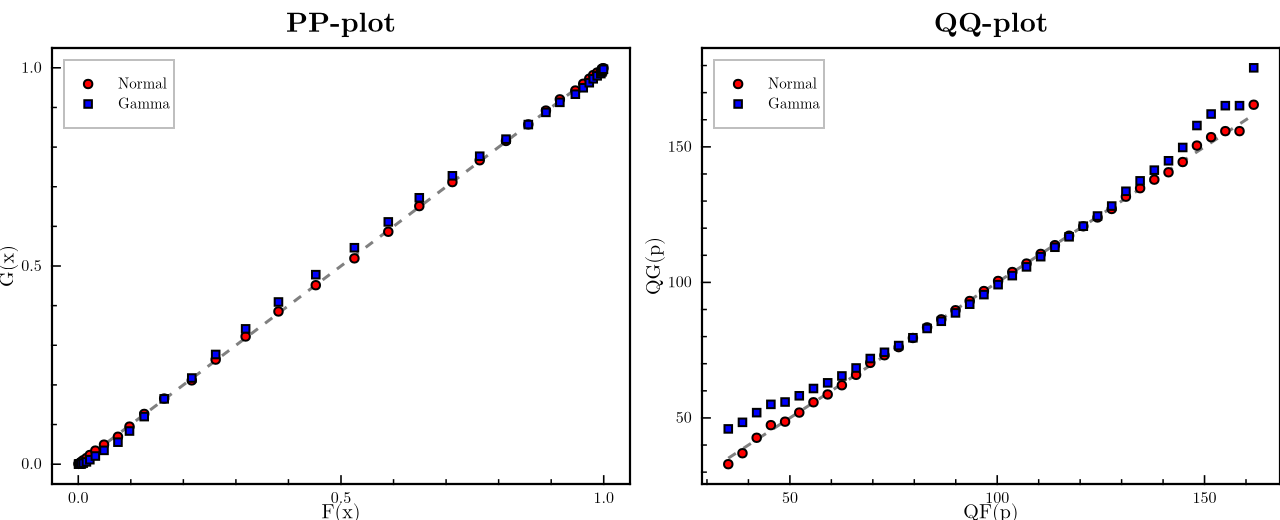

In [9]:
# PP-Plot and QQ-Plot
Fn = GOF.make_EDF(data, x)

fig = Figure(size=(2*320, 260))
ax1 = Axis(fig[1,1], xlabel="F(x)", ylabel="G(x)", title="PP-plot")
ax2 = Axis(fig[1,2], xlabel="QF(p)", ylabel="QG(p)", title="QQ-plot")

# PP
lines!(ax1, 0:1e-2:1, 0:1e-2:1, linestyle=:dash, color=:gray)
scatter!(ax1, Fn, cdf(Normal(μ, σ), x), label="Normal", color=:red)
scatter!(ax1, Fn, cdf(Gamma(α, θ), x), label="Gamma", color=:blue)
axislegend(ax1, position=:lt, framevisible=true)

# QQ
lines!(ax2, minimum(x):1e-2:maximum(x), minimum(x):1e-2:maximum(x), linestyle=:dash, color=:gray)
scatter!(ax2, x, quantile(Normal(μ, σ), Fn), label="Normal", color=:red)
scatter!(ax2, x, quantile(Gamma(α, θ), Fn), label="Gamma", color=:blue)
axislegend(ax2, position=:lt, framevisible=true)

fig

In [10]:
G_n(x) = cdf(Normal(μ, σ), x)
G_g(x) = cdf(Gamma(α, θ), x)

Q_n(u) = quantile(Normal(μ, σ), u)
Q_g(u) = quantile(Gamma(α, θ), u)

println("--- Chi2 ---")
p_n = GOF.MC_gof(data, G_n, Q_n, GOF.chi2; nbins=40)
p_g = GOF.MC_gof(data, G_g, Q_g, GOF.chi2; nbins=40)

println("p-value Normal:  $p_n")
println("p-value Gamma :  $p_g")
println()

println("--- Kolmogorov-Smirnov ---")
p_n = GOF.MC_gof(data, G_n, Q_n, GOF.KS)
p_g = GOF.MC_gof(data, G_g, Q_g, GOF.KS)

println("p-value Normal:  $p_n")
println("p-value Gamma :  $p_g")
println()

println("--- Anderson-Darling ---")
p_n = GOF.MC_gof(data, G_n, Q_n, GOF.AD)
p_g = GOF.MC_gof(data, G_g, Q_g, GOF.AD)

println("p-value Normal:  $p_n")
println("p-value Gamma :  $p_g")
println()

println("--- Cramer-von Mises ---")
p_n = GOF.MC_gof(data, G_n, Q_n, GOF.CvM)
p_g = GOF.MC_gof(data, G_g, Q_g, GOF.CvM)

println("p-value Normal:  $p_n")
println("p-value Gamma :  $p_g")

--- Chi2 ---
p-value Normal:  0.9733
p-value Gamma :  0.0058

--- Kolmogorov-Smirnov ---
p-value Normal:  0.9817
p-value Gamma :  0.0245

--- Anderson-Darling ---
p-value Normal:  0.9994
p-value Gamma :  0.0091

--- Cramer-von Mises ---
p-value Normal:  0.9931
p-value Gamma :  0.0263
